## 1. Análisis Exploratorio de Datos (EDA)
Visualizamos las distribuciones originales de las frecuencias de palabras y caracteres en el dataset Spambase.

In [88]:
!pip install ucimlrepo -q
!pip install optuna -q

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# Obtener el dataset desde el repositorio UCI (Spambase)
spambase = fetch_ucirepo(id=94)

# Separar en características (X) y variable objetivo (y)
X = spambase.data.features
y = spambase.data.targets

# Conversión a arreglos de NumPy para procesamiento matricial
x = X.to_numpy().reshape((-1, 57))
y_np = y.to_numpy().reshape((-1, 1))

print(f"Datos cargados. Dimensiones de X: {X.shape}")

Datos cargados. Dimensiones de X: (4601, 57)


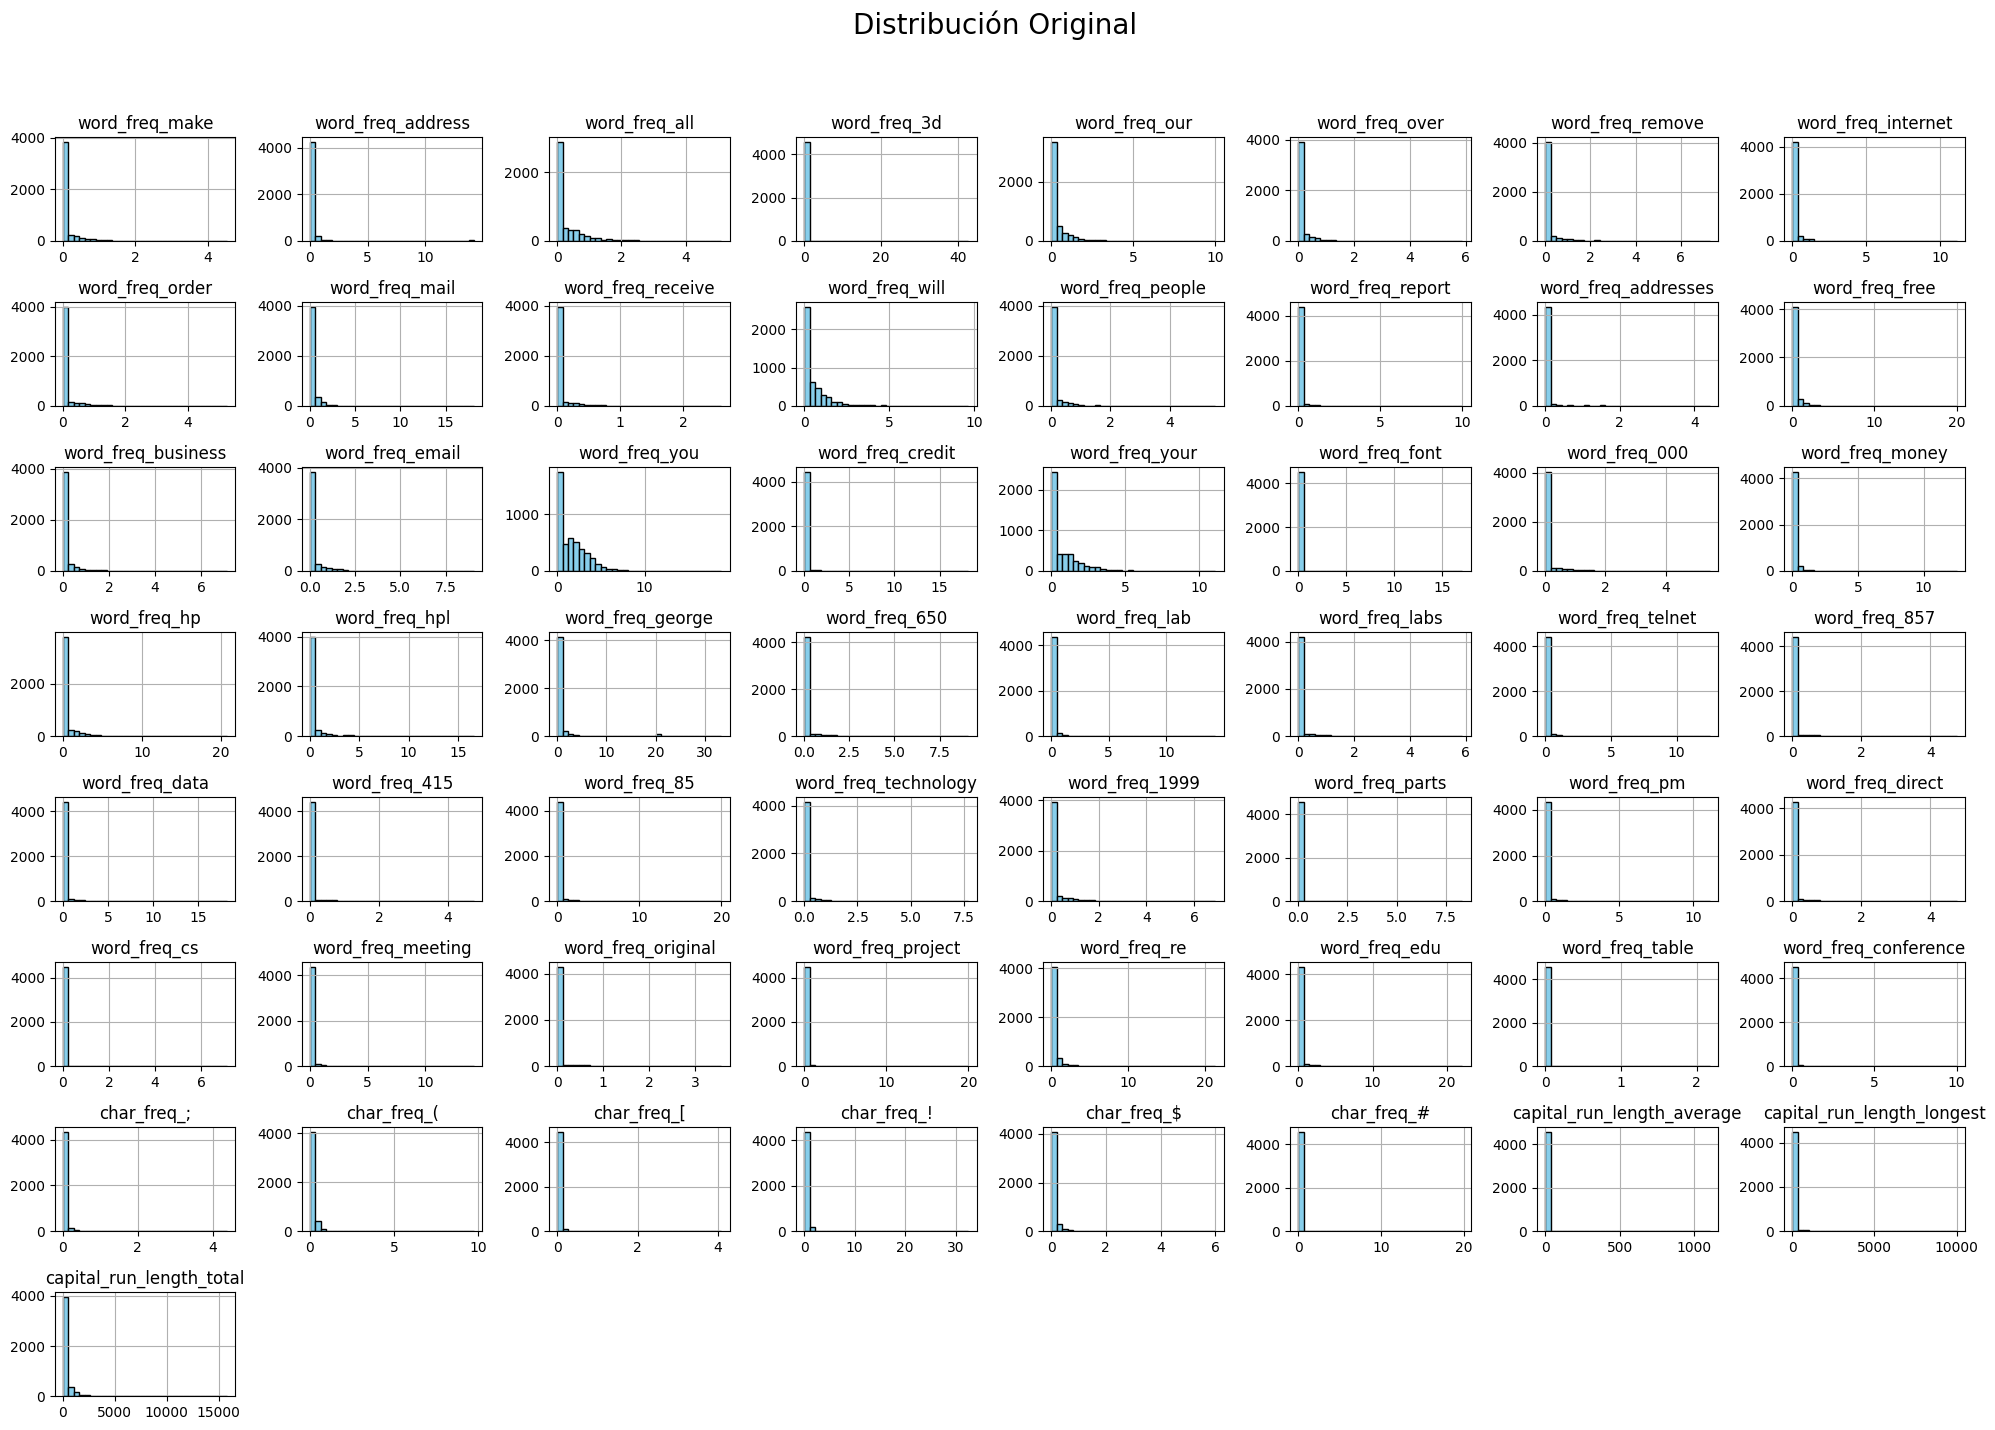

In [90]:
# Visualización masiva de distribuciones
X.hist(figsize=(20, 15), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribución Original", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Procesamiento
Aplicamos transformación logarítmica y creación de variables de urgencia para corregir el sesgo y mejorar la linealidad.

/tmp/ipykernel_12430/407197414.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values[:15], y=correlations.index[:15], palette='viridis')


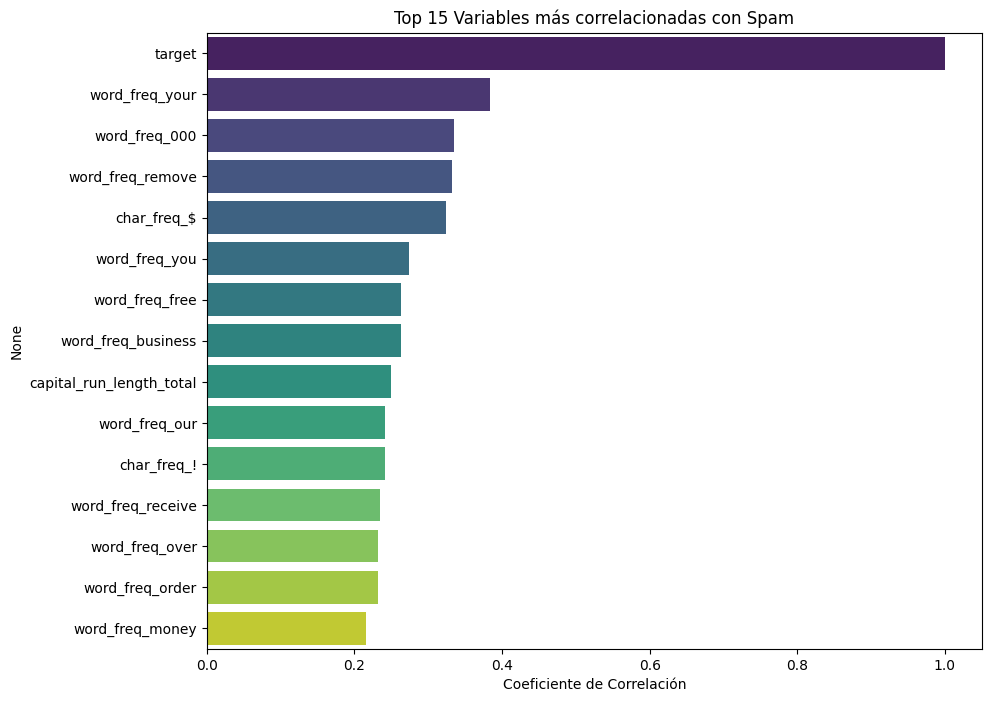

In [91]:
# Análisis de Correlación con el Target
temp_df = X.copy()
temp_df['target'] = y.values

# Calculamos correlaciones
correlations = temp_df.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values[:15], y=correlations.index[:15], palette='viridis')
plt.title("Top 15 Variables más correlacionadas con Spam")
plt.xlabel("Coeficiente de Correlación")
plt.show()

### Impacto de las Nuevas Features
Validamos la utilidad del `urgency_score` mediante su correlación con la variable objetivo.

/tmp/ipykernel_12430/1044730790.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_new.values[:15], y=corr_new.index[:15], palette='magma')


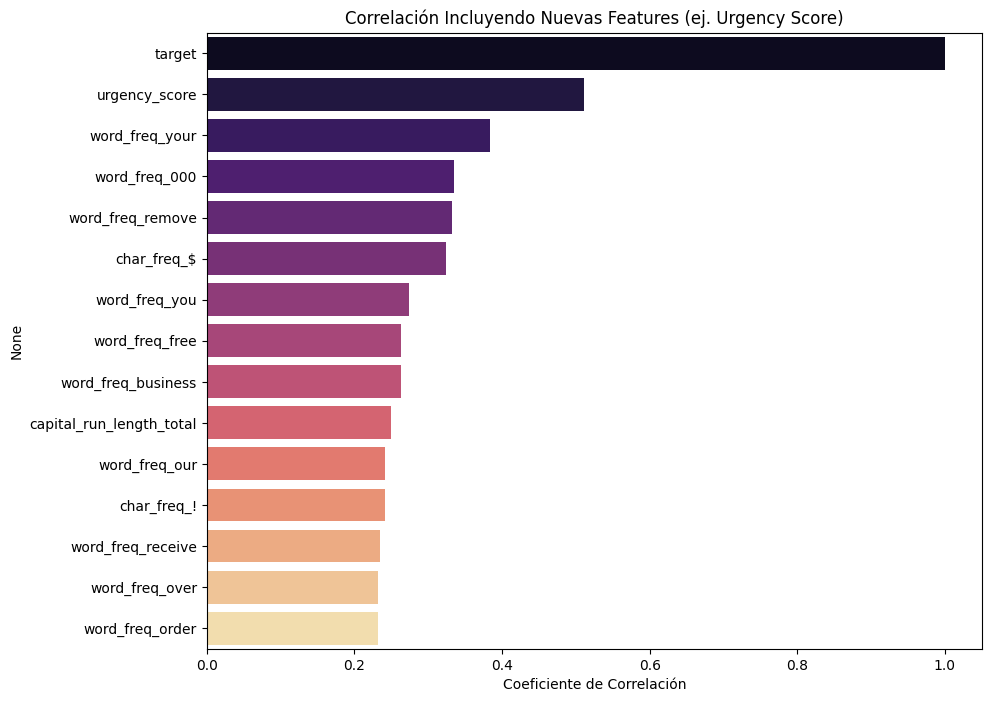

In [92]:
df_analisis = X.copy()

urgency_words = ['word_freq_free', 'word_freq_money', 'word_freq_000', 'word_freq_your']
df_analisis['urgency_score'] = df_analisis[urgency_words].sum(axis=1)
df_analisis['target'] = y.values

# Calculamos y graficamos
corr_new = df_analisis.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_new.values[:15], y=corr_new.index[:15], palette='magma')
plt.title("Correlación Incluyendo Nuevas Features (ej. Urgency Score)")
plt.xlabel("Coeficiente de Correlación")
plt.show()

### Matriz de Correlación General
Analizamos las dependencias entre variables para detectar multicolinealidad antes del modelado.

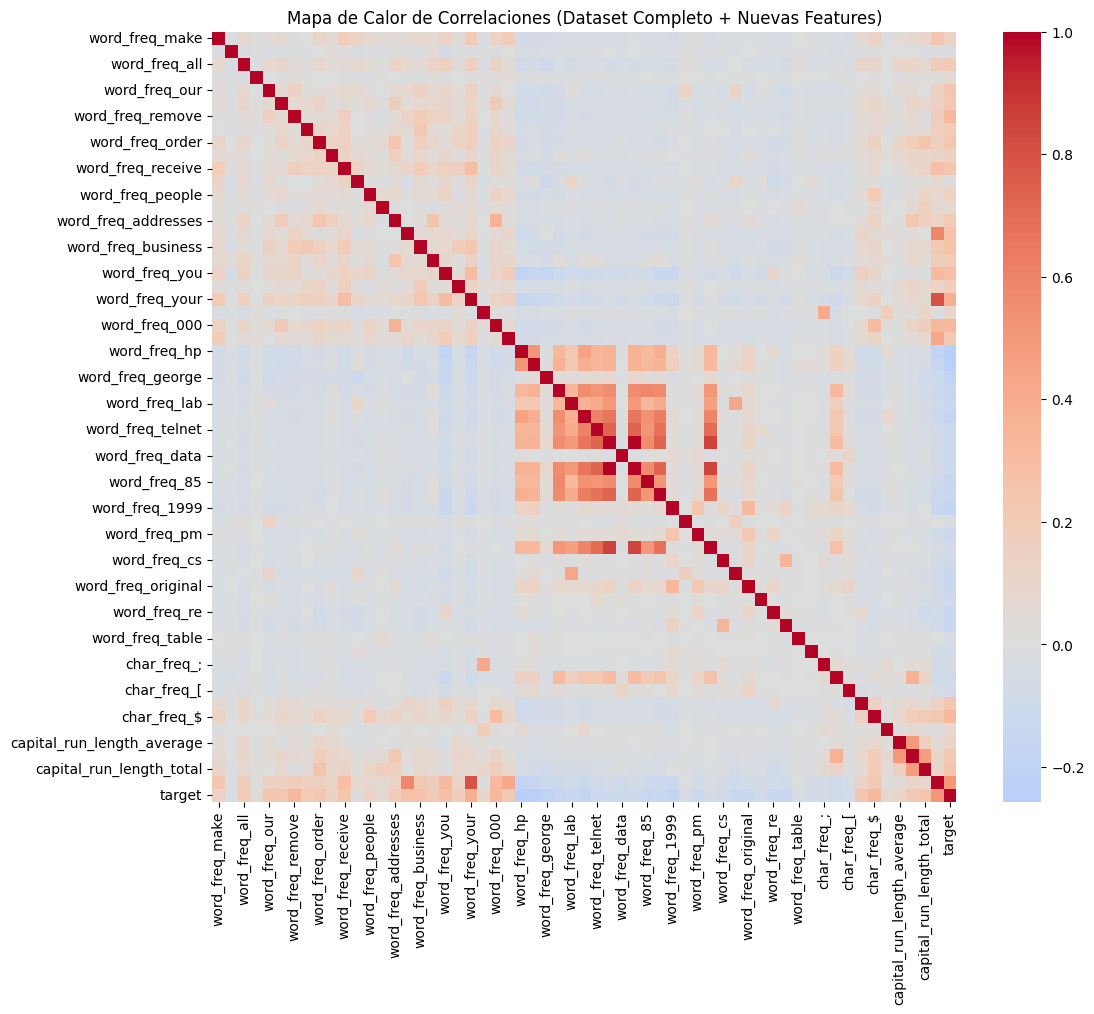

In [93]:
# Cálculo de la matriz de correlación
plt.figure(figsize=(12, 10))
corr_matrix = df_analisis.corr()

# Dibujamos el mapa de calor
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Mapa de Calor de Correlaciones (Dataset Completo + Nuevas Features)")
plt.show()

In [94]:
class LogisticRegressionElasticNet:
    def __init__(self, alpha=0.01, lambda_param=0.5, learning_rate=0.01, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.lambda_param = lambda_param
        self.lr = learning_rate
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.train_losses = []
        self.val_losses = []

    def _sigmoid(self, z):
        z_clipped = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z_clipped))

    def _compute_loss(self, X, y):
        m = y.shape[0]
        y_pred = self._sigmoid(X @ self.weights)
        epsilon = 1e-10
        y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
        bce = - (1/m) * np.sum(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
        l2_penalty = self.alpha * self.lambda_param * np.sum(self.weights[1:]**2)
        l1_penalty = self.alpha * (1 - self.lambda_param) * np.sum(np.abs(self.weights[1:]))
        return bce + l2_penalty + l1_penalty

    def _compute_gradients(self, X, y):
        m = y.shape[0]
        y_pred = self._sigmoid(X @ self.weights)
        dw = (X.T @ (y_pred - y)) / m
        reg_l2 = self.alpha * self.lambda_param * 2 * self.weights
        reg_l1 = self.alpha * (1 - self.lambda_param) * np.sign(self.weights)
        reg_l1[0] = 0
        reg_l2[0] = 0
        return dw + reg_l2 + reg_l1

    def fit(self, X_train, y_train, X_val=None, y_val=None, graph=True, log_x=False):
        np.random.seed(42)
        m_train, n_features = X_train.shape
        y_train = y_train.flatten()
        if y_val is not None: y_val = y_val.flatten()
        X_train_bias = np.hstack((np.ones((m_train, 1)), X_train))
        if X_val is not None: X_val_bias = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
        self.weights = np.random.randn(n_features + 1) * 0.01
        self.train_losses = []
        self.val_losses = []
        for i in range(self.max_iter):
            loss_train = self._compute_loss(X_train_bias, y_train)
            self.train_losses.append(loss_train)
            if X_val is not None and y_val is not None:
                self.val_losses.append(self._compute_loss(X_val_bias, y_val))
            if loss_train < self.tol: break
            dw = self._compute_gradients(X_train_bias, y_train)
            self.weights -= self.lr * dw
        if graph:
            self._plot_learning_curve(log_x=log_x)
        return self

    def predict_proba(self, X):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        return self._sigmoid(X_bias @ self.weights)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def _plot_learning_curve(self, log_x=False):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        iterations = np.arange(1, len(self.train_losses) + 1)
        axes[0].plot(iterations, self.train_losses, label='Train')
        if self.val_losses: axes[0].plot(iterations, self.val_losses, label='Validation')
        axes[0].set_title('Escala Lineal (Error vs Iteración)')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[1].plot(iterations, self.train_losses, label='Train')
        if self.val_losses: axes[1].plot(iterations, self.val_losses, label='Validation')
        if log_x: axes[1].set_xscale('log')
        axes[1].set_yscale('log')
        axes[1].set_title('Escala Logarítmica')
        axes[1].legend()
        plt.show()

In [95]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, auc)

class ModelEvaluator:
    """
    Utilidad para generar reportes, matrices de confusión y análisis de umbrales.
    """
    def __init__(self, target_names=['No Spam', 'Spam']):
        self.target_names = target_names

    def reportar_y_graficar(self, y_true, y_prob, threshold=0.5):
        y_pred = (y_prob >= threshold).astype(int)
        print("=" * 40)
        print(f"REPORTE (Umbral: {threshold})")
        print("=" * 40)
        print(classification_report(y_true, y_pred, target_names=self.target_names))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=self.target_names).plot(cmap='Blues', ax=axes[0])

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}')
        axes[1].plot([0, 1], [0, 1], '--')
        axes[1].legend(loc="lower right")
        plt.show()

    def graficar_metricas_vs_umbral(self, y_true, y_prob):
        umbrales = np.linspace(0, 0.999, 100)
        results = {'Acc': [], 'Prec': [], 'Rec': [], 'F1': []}
        for t in umbrales:
            y_p = (y_prob >= t).astype(int)
            results['Acc'].append(accuracy_score(y_true, y_p))
            results['Prec'].append(precision_score(y_true, y_p, zero_division=1))
            results['Rec'].append(recall_score(y_true, y_p))
            results['F1'].append(f1_score(y_true, y_p, zero_division=0))

        plt.figure(figsize=(10, 6))
        for k, v in results.items(): plt.plot(umbrales, v, label=k)
        plt.title('Métricas vs Umbral')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score

# 1. Asegurarnos de tener los datos (usando las variables 'x' e 'y' de tu código)
# x = X.to_numpy().reshape((-1,57))
# y = y.to_numpy().reshape((-1,1))

# 2. Dividir los datos en conjunto de entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [97]:
def build_pipe_procesamiento_escale(x):
  scaler = StandardScaler()
  scaler.fit_transform(x)
  #X_test_scaled = scaler.transform(X_test)
  return scaler

In [98]:
def build_pipe_procesamiento_escale(x):
  scaler = StandardScaler()
  scaler.fit_transform(x)
  return scaler

class new_feature:
  scaler = None
  def get_new_features(self, X):
    X_proc = X.copy()

    # Dominios y Urgencia
    prof_words = ['word_freq_lab', 'word_freq_data', 'word_freq_project', 'word_freq_meeting']
    urgency_words = ['word_freq_free', 'word_freq_money', 'word_freq_000', 'word_freq_your']
    ham_markers = ['word_freq_george', 'word_freq_hp', 'word_freq_edu', 'word_freq_meeting']

    X_proc['prof_score'] = X_proc[[c for c in prof_words if c in X_proc.columns]].sum(axis=1)
    X_proc['urgency_score'] = X_proc[[c for c in urgency_words if c in X_proc.columns]].sum(axis=1)
    X_proc['ham_identity_score'] = X_proc[[c for c in ham_markers if c in X_proc.columns]].sum(axis=1)

    # Puntuación y Ratios
    X_proc['punct_density_score'] = X_proc[['char_freq_!', 'char_freq_$', 'char_freq_#', 'char_freq_(']].sum(axis=1)
    X_proc['shouting_punct_ratio'] = (X_proc['char_freq_!'] + X_proc['char_freq_$']) / (X_proc['punct_density_score'] + 0.01)

    # Carga Visual y Ratios Monetarios
    X_proc['visual_overload_score'] = np.log1p(X_proc['capital_run_length_total']) * (X_proc['char_freq_!'] + X_proc['char_freq_$'])
    X_proc['money_personal_ratio'] = (X_proc['word_freq_money'] + X_proc['word_freq_credit']) / (X_proc['word_freq_you'] + 0.01)

    # Diversidad y Complejidad
    key_word_cols = [c for c in X_proc.columns if 'word_freq' in c]
    X_proc['keyword_diversity_score'] = (X_proc[key_word_cols] > 0).sum(axis=1)

    punct_cols_ext = ['char_freq_!', 'char_freq_$', 'char_freq_#', 'char_freq_(', 'char_freq_[', 'char_freq_;']
    X_proc['punct_complexity_score'] = (X_proc[punct_cols_ext] > 0).sum(axis=1)
    return X_proc
  def fit_transform(self, X, columns=[], y=None):
    X = pd.DataFrame(X, columns=columns)
    X_proc = self.get_new_features(X)
    X_proc = np.log1p(X_proc)
    self.scaler = build_pipe_procesamiento_escale(X_proc)
    return

  def transform(self, X, columns=[], y=None):
    X = pd.DataFrame(X, columns=columns)
    X_proc = self.get_new_features(X)
    # Transformación Logarítmica para reducir sesgo
    X_proc = np.log1p(X_proc)
    return self.scaler.transform(X_proc)


def build_pipe_procesamiento_features(X, columns=[], random_state=42):
  generador_features = new_feature()
  generador_features.fit_transform(X, columns=columns)
  return generador_features


In [99]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def procesar_datos_spambase(X, y, umbral_correlacion=0.8, random_state=42):
    """
    Pipeline consolidado: Feature Engineering -> Log Transform -> Drop Collinearity -> Split -> Scaling
    """
    df_X = pd.DataFrame(X.copy()) if not isinstance(X, pd.DataFrame) else X.copy()

    # 1. Feature Engineering Consolidado
    # Urgencia y Profesionalismo
    urgency_words = ['word_freq_free', 'word_freq_money', 'word_freq_000', 'word_freq_your']
    prof_words = ['word_freq_lab', 'word_freq_data', 'word_freq_project', 'word_freq_meeting']

    df_X['urgency_score'] = df_X[[c for c in urgency_words if c in df_X.columns]].sum(axis=1)
    df_X['prof_score'] = df_X[[c for c in prof_words if c in df_X.columns]].sum(axis=1)

    # Puntuación y Ratios
    df_X['punct_density_score'] = df_X[['char_freq_!', 'char_freq_$', 'char_freq_#', 'char_freq_(']].sum(axis=1)
    df_X['visual_overload_score'] = np.log1p(df_X['capital_run_length_total']) * (df_X['char_freq_!'] + df_X['char_freq_$'])

    # 2. Transformación Logarítmica
    df_X_log = np.log1p(df_X)

    # 3. Eliminación de Multicolinealidad
    matriz_corr = df_X_log.corr().abs()
    triang = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    to_drop = [c for c in triang.columns if any(triang[c] > umbral_correlacion)]
    df_clean = df_X_log.drop(columns=to_drop)

    # 4. Split Estratificado
    X_train, X_val, y_train, y_val = train_test_split(
        df_clean, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # 5. Escalado Estándar
    sc = StandardScaler()
    return sc.fit_transform(X_train), sc.transform(X_val), y_train, y_val

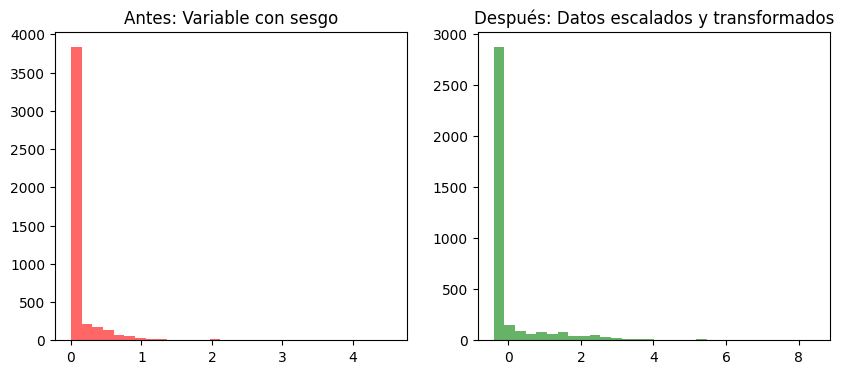

In [100]:
# Visualización post-procesamiento
X_train_p, X_val_p, y_train_p, y_val_p = procesar_datos_spambase(X, y)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(X.iloc[:, 0], bins=30, color='red', alpha=0.6)
plt.title("Antes: Variable con sesgo")

plt.subplot(1, 2, 2)
plt.hist(X_train_p[:, 0], bins=30, color='green', alpha=0.6)
plt.title("Después: Datos escalados y transformados")
plt.show()

## 2. Entrenamiento y Optimización
Entrenamos el modelo Elastic Net optimizando hiperparámetros con Optuna para maximizar el F1-Score.

In [113]:
import optuna
from sklearn.model_selection import StratifiedKFold

class HyperparameterTuner:
    def __init__(self, model_class, n_splits=5, n_trials=30):
        self.model_class = model_class
        self.n_splits = n_splits
        self.n_trials = n_trials
        self.study = None

    def optimize(self, X, y, param_space_fn):
        def objective(trial):
            params = param_space_fn(trial)
            skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
            fold_f1s = []

            y_arr = y.values.flatten() if hasattr(y, 'values') else y.flatten()

            for tr_idx, vl_idx in skf.split(X, y_arr):
                model = self.model_class(**params)
                model.fit(X[tr_idx], y_arr[tr_idx], graph=False)
                preds = model.predict(X[vl_idx])
                fold_f1s.append(f1_score(y_arr[vl_idx], preds))

            return np.mean(fold_f1s)

        self.study = optuna.create_study(direction='maximize')
        self.study.optimize(objective, n_trials=self.n_trials)
        return self.study

# Ejecución de la Optimización
X_train_f, X_val_f, y_train_f, y_val_f = procesar_datos_spambase(X, y)

def space(trial):
    return {
        'alpha': trial.suggest_float('alpha', 1e-5, 0.1, log=True),
        'lambda_param': trial.suggest_float('lambda_param', 0, 1),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.5, log=True)
    }

tuner = HyperparameterTuner(LogisticRegressionElasticNet, n_trials=20)
study = tuner.optimize(X_train_f, y_train_f, space)
print(f"Mejores parámetros: {study.best_params}")

[I 2026-05-02 03:11:38,263] A new study created in memory with name: no-name-ca0e7dee-6e5e-4775-bb08-de2d5dc1cc94
[I 2026-05-02 03:11:43,375] Trial 0 finished with value: 0.8981864712648161 and parameters: {'alpha': 0.01687895304578233, 'lambda_param': 0.15093142666206394, 'learning_rate': 0.18076550791629215}. Best is trial 0 with value: 0.8981864712648161.
[I 2026-05-02 03:11:47,107] Trial 1 finished with value: 0.8640719979604677 and parameters: {'alpha': 0.057932841539538815, 'lambda_param': 0.23779094866234984, 'learning_rate': 0.011674161043781425}. Best is trial 0 with value: 0.8981864712648161.
[I 2026-05-02 03:11:52,570] Trial 2 finished with value: 0.9068572556449729 and parameters: {'alpha': 0.00014175999752478972, 'lambda_param': 0.48394064685845806, 'learning_rate': 0.017012916417947638}. Best is trial 2 with value: 0.9068572556449729.
[I 2026-05-02 03:11:55,808] Trial 3 finished with value: 0.9193033836963769 and parameters: {'alpha': 0.0013670253253189847, 'lambda_param'

Mejores parámetros: {'alpha': 0.00012725431092163814, 'lambda_param': 0.01614745233466873, 'learning_rate': 0.49809874013339256}


### Análisis de Estabilidad: Top 10 Trials
Visualizamos la distribución del Loss en los folds de validación cruzada para los 10 mejores experimentos, permitiendo evaluar la varianza y robustez de los hiperparámetros seleccionados.

Calculando métricas de folds para los top 10 trials...


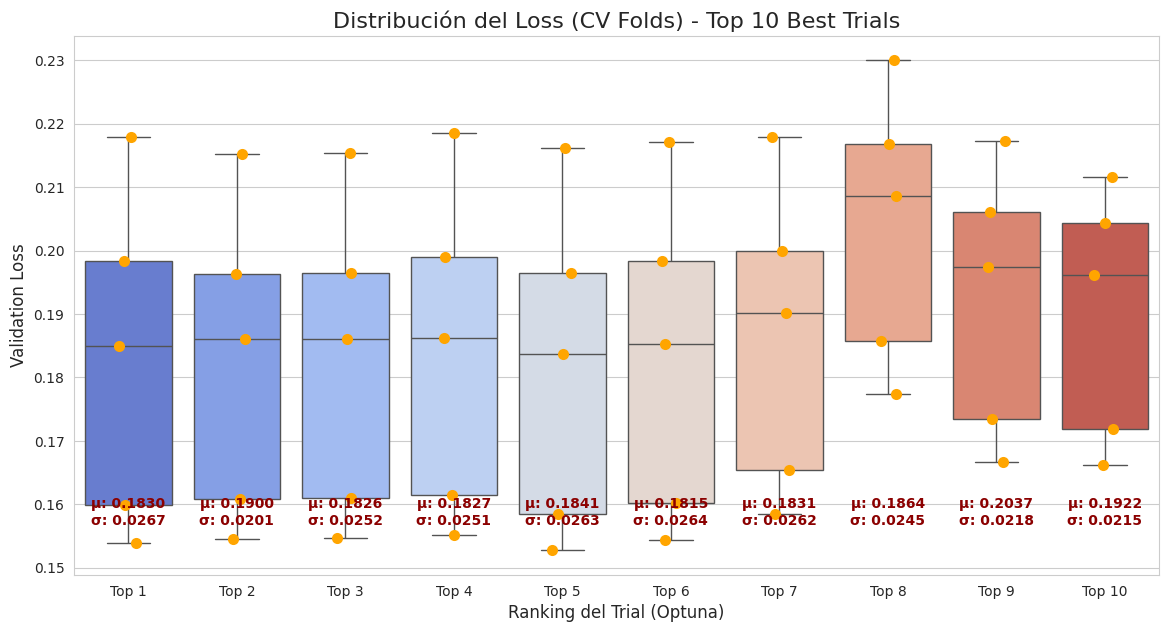

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraer los 10 mejores trials basados en el valor (F1-Score alto)
top_10_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:10]

def get_fold_losses(trial_params, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    losses = []
    y_arr = y.values.flatten() if hasattr(y, 'values') else y.flatten()

    for tr_idx, vl_idx in skf.split(X, y_arr):
        model = LogisticRegressionElasticNet(**trial_params)
        # Entrenamos y obtenemos el loss final de validación
        model.fit(X[tr_idx], y_arr[tr_idx], X_val=X[vl_idx], y_val=y_arr[vl_idx], graph=False)
        losses.append(model.val_losses[-1])
    return losses

print("Calculando métricas de folds para los top 10 trials...")
data_plot = []
for i, t in enumerate(top_10_trials):
    losses = get_fold_losses(t.params, X_train_f, y_train_f)
    for l in losses:
        data_plot.append({'Trial_Rank': f'Top {i+1}', 'Loss': l})

df_top_trials = pd.DataFrame(data_plot)

# 2. Graficar
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
# Se añade hue='Trial_Rank' para evitar el FutureWarning y legend=False
ax = sns.boxplot(x='Trial_Rank', y='Loss', data=df_top_trials, palette='coolwarm', hue='Trial_Rank', legend=False)
sns.stripplot(x='Trial_Rank', y='Loss', data=df_top_trials, color="orange", jitter=0.1, size=8)

# 3. Añadir etiquetas de Media y Desv
stats = df_top_trials.groupby('Trial_Rank')['Loss'].agg(['mean', 'std']).reset_index()
for i, row in stats.iterrows():
    ax.text(i, ax.get_ylim()[0] * 1.05, f"μ: {row['mean']:.4f}\nσ: {row['std']:.4f}",
            ha='center', va='bottom', fontweight='bold', color='darkred', fontsize=10)

plt.title("Distribución del Loss (CV Folds) - Top 10 Best Trials", fontsize=16)
plt.xlabel("Ranking del Trial (Optuna)", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.show()

## 3. Evaluación Final
Evaluamos el rendimiento del modelo final mediante métricas de clasificación y curvas de aprendizaje.

### Resultados del Modelo Optimizado
Generamos el reporte de métricas y analizamos el impacto del umbral de decisión en la precisión y el recall.

Entrenando modelo final con parámetros optimizados...


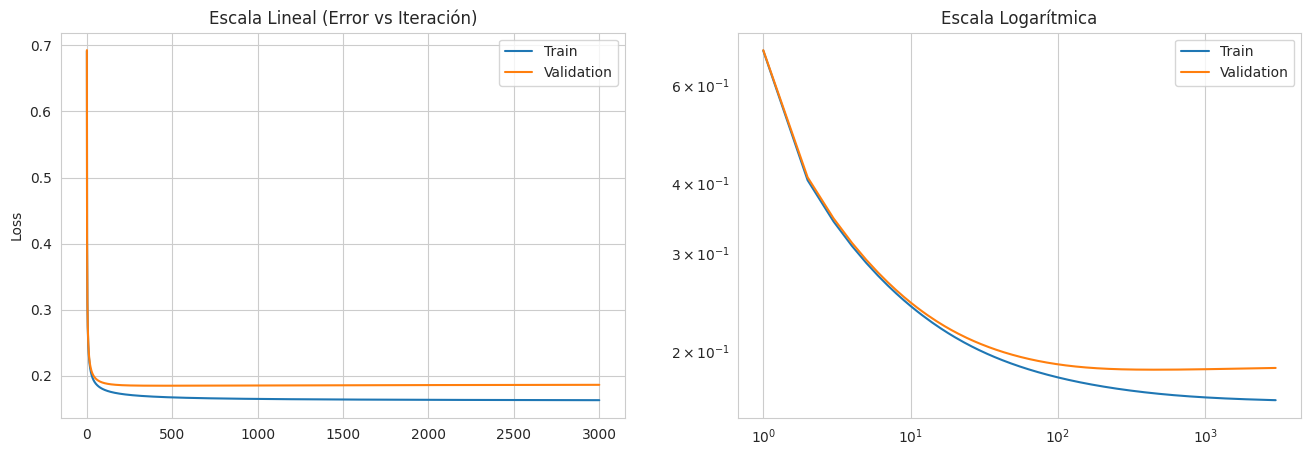


--- Comparativa de Rendimiento (Check Overfitting) ---


,Métrica,Entrenamiento,Validación
0,Accuracy,0.945924,0.932682
1,Precision,0.939564,0.916898
2,Recall,0.922069,0.911846
3,F1-Score,0.930734,0.914365


REPORTE (Umbral: 0.5)
              precision    recall  f1-score   support

     No Spam       0.94      0.95      0.94       558
        Spam       0.92      0.91      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



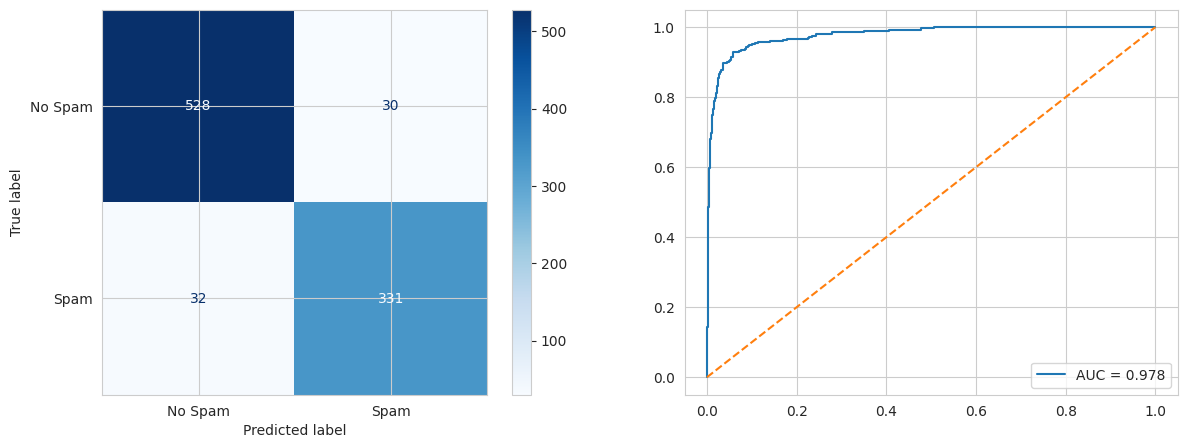

In [118]:
final_model = LogisticRegressionElasticNet(
    **study.best_params,
    max_iter=3000
)

# 2. Entrenamiento definitivo
print("Entrenando modelo final con parámetros optimizados...")
y_train_final_np = y_train_f.values.flatten()
y_val_final_np = y_val_f.values.flatten()

final_model.fit(X_train_f, y_train_final_np, X_val=X_val_f, y_val=y_val_final_np, graph=True, log_x=True)

# 3. Comparación de Overfitting (Train vs Val)
y_prob_train = final_model.predict_proba(X_train_f)
y_prob_val = final_model.predict_proba(X_val_f)
y_pred_train = (y_prob_train >= 0.5).astype(int)
y_pred_val = (y_prob_val >= 0.5).astype(int)

metrics_comparison = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Entrenamiento': [
        accuracy_score(y_train_final_np, y_pred_train),
        precision_score(y_train_final_np, y_pred_train),
        recall_score(y_train_final_np, y_pred_train),
        f1_score(y_train_final_np, y_pred_train)
    ],
    'Validación': [
        accuracy_score(y_val_final_np, y_pred_val),
        precision_score(y_val_final_np, y_pred_val),
        recall_score(y_val_final_np, y_pred_val),
        f1_score(y_val_final_np, y_pred_val)
    ]
}

df_overfitting = pd.DataFrame(metrics_comparison)
print("\n--- Comparativa de Rendimiento (Check Overfitting) ---")
display(df_overfitting)

# 4. Evaluación Detallada en Validación
evaluador_final = ModelEvaluator()
evaluador_final.reportar_y_graficar(y_val_final_np, y_prob_val, threshold=0.5)

## 4. Benchmark de Estrategias
Comparamos cinco configuraciones de procesamiento para confirmar que 'Log + Escalado' es la estrategia ganadora.

### Configuración de los Experimentos
Utilizaremos los mismos hiperparámetros encontrados por Optuna y un límite de 2000 iteraciones para asegurar una comparación justa.

In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Preparación de Datos: Train/Val Split
X_train_full, X_test_lock, y_train_full, y_test_lock = train_test_split(x, y_np, test_size=0.2, random_state=42, stratify=y_np)
X_tr_exp, X_val_exp, y_tr_exp, y_val_exp = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# 2. Hiperparámetros estandarizados
params_bench = {
    'alpha': study.best_params['alpha'],
    'lambda_param': study.best_params['lambda_param'],
    'learning_rate': study.best_params['learning_rate'],
    'max_iter': 2000
}

resultados_benchmark = []

def registrar_resultado(nombre, y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    resultados_benchmark.append({
        'Experimento': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    })

# --- EXPERIMENTO 1: Sin Procesamiento (Raw) ---
model_1 = LogisticRegressionElasticNet(**params_bench)
model_1.fit(X_tr_exp, y_tr_exp, graph=False)
registrar_resultado("1. Sin Procesamiento", y_val_exp, model_1.predict_proba(X_val_exp))

# --- EXPERIMENTO 2: Solo Escalado Simple ---
sc_2 = StandardScaler()
X_tr_2 = sc_2.fit_transform(X_tr_exp)
X_vl_2 = sc_2.transform(X_val_exp)
model_2 = LogisticRegressionElasticNet(**params_bench)
model_2.fit(X_tr_2, y_tr_exp, graph=False)
registrar_resultado("2. Solo Escalado Simple", y_val_exp, model_2.predict_proba(X_vl_2))

# --- EXPERIMENTO 3: Log + Escalado ---
X_tr_3 = np.log1p(X_tr_exp)
X_vl_3 = np.log1p(X_val_exp)
sc_3 = StandardScaler()
X_tr_3_sc = sc_3.fit_transform(X_tr_3)
X_vl_3_sc = sc_3.transform(X_vl_3)
model_3 = LogisticRegressionElasticNet(**params_bench)
model_3.fit(X_tr_3_sc, y_tr_exp, graph=False)
registrar_resultado("3. Log + Escalado", y_val_exp, model_3.predict_proba(X_vl_3_sc))

# --- EXPERIMENTO 4: Full Features (Original + Nuevas) ---
generador_4 = new_feature()
df_tr_exp = pd.DataFrame(X_tr_exp, columns=X.columns)
df_vl_exp = pd.DataFrame(X_val_exp, columns=X.columns)

X_tr_4 = generador_4.get_new_features(df_tr_exp)
X_vl_4 = generador_4.get_new_features(df_vl_exp)

sc_4 = StandardScaler()
X_tr_4_sc = sc_4.fit_transform(np.log1p(X_tr_4))
X_vl_4_sc = sc_4.transform(np.log1p(X_vl_4))
model_4 = LogisticRegressionElasticNet(**params_bench)
model_4.fit(X_tr_4_sc, y_tr_exp, graph=False)
registrar_resultado("4. Añadiendo Features Nuevas", y_val_exp, model_4.predict_proba(X_vl_4_sc))

# --- EXPERIMENTO 5: Híbrido (Features Eng + Sin variables originales) ---
fuentes_ingenieria = ['word_freq_lab', 'word_freq_data', 'word_freq_project', 'word_freq_meeting', 'word_freq_free', 'word_freq_money', 'word_freq_000', 'word_freq_your', 'word_freq_george', 'word_freq_hp', 'word_freq_edu', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'char_freq_(', 'capital_run_length_total', 'word_freq_credit', 'word_freq_you', 'char_freq_[', 'char_freq_;']

cols_5 = [c for c in X_tr_4.columns if c not in fuentes_ingenieria]
X_tr_5 = X_tr_4[cols_5]
X_vl_5 = X_vl_4[cols_5]

sc_5 = StandardScaler()
X_tr_5_sc = sc_5.fit_transform(np.log1p(X_tr_5))
X_vl_5_sc = sc_5.transform(np.log1p(X_vl_5))
model_5 = LogisticRegressionElasticNet(**params_bench)
model_5.fit(X_tr_5_sc, y_tr_exp, graph=False)
registrar_resultado("5. Features Nuevas (Sin Originales Input)", y_val_exp, model_5.predict_proba(X_vl_5_sc))

### Resumen de Resultados
Visualización comparativa de Accuracy, Precision y F1-Score para cada experimento realizado.

In [117]:
df_resumen = pd.DataFrame(resultados_benchmark)
display(df_resumen)

,Experimento,Accuracy,Precision,Recall,F1-Score
0,1. Sin Procesamiento,0.694293,0.777778,0.313793,0.447174
1,2. Solo Escalado Simple,0.927989,0.934066,0.879310,0.905861
2,3. Log + Escalado,0.947011,0.928328,0.937931,0.933105
3,4. Añadiendo Features Nuevas,0.947011,0.928328,0.937931,0.933105
4,5. Features Nuevas (Sin Originales Input),0.940217,0.924138,0.924138,0.924138
